<a href="https://colab.research.google.com/github/srivastavalove736/CODSOFT_TASKSNO/blob/main/TASK_4_CUSTOMER_DATA_ANALYSIS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

=== CUSTOMER DATASET PREVIEW ===
  Customer_ID  Age  Gender  Location  Total_Purchases  Total_Spend  \
0   CUST_1000   56  Female     Rural               11      1026.54   
1   CUST_1001   69  Female     Urban               18      1063.08   
2   CUST_1002   46    Male     Urban               47       507.65   
3   CUST_1003   32    Male  Suburban               12      1777.74   
4   CUST_1004   60  Female  Suburban                9      1554.43   

  Preferred_Category  Avg_Order_Value  
0           Clothing            93.32  
1        Electronics            59.06  
2           Clothing            10.80  
3               Home           148.15  
4        Electronics           172.71  

=== CUSTOMER DISTRIBUTION BY TIER ===
Customer_Tier
High Spender      68
Medium Spender    66
Low Spender       66
Name: count, dtype: int64

=== SEGMENT ANALYSIS BY AGE GROUP ===
             Age_Group  Customer_Count  Total_Revenue  Average_Spend  \
0        Gen Z (18-25)              33       43947.84

/tmp/ipykernel_3749/682980207.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Total_Revenue', data=segment_analysis, ax=axes[0], palette='Blues_d')


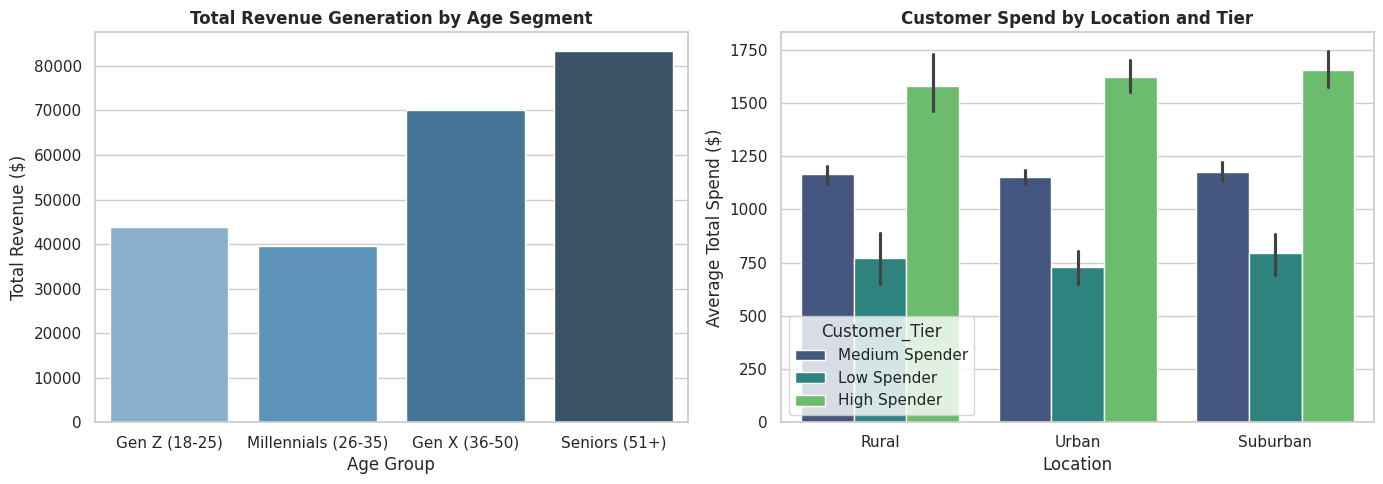


        CUSTOMER ANALYSIS & STRATEGY REPORT       
1. High-Value Demographic:
   - Target Segment: Gen Z (18-25) shows the highest average spend per customer.
   - Top Generating Location: Urban accounts for the highest total revenue share.

2. Strategic Recommendations:
   - Loyalty Program: Launch an exclusive VIP rewards tier targeting 'High Spender' customers to improve retention.
   - Targeted Marketing: Focus ad campaigns on Gen Z (18-25) within Urban regions promoting preferred product lines.
   - Re-Engagement: Offer promotional discounts to 'Low Spender' segments to boost purchase frequency.

Report saved as 'customer_strategy_recommendations.txt'


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

np.random.seed(42)
n_customers = 200

customer_data = {
    'Customer_ID': [f'CUST_{1000 + i}' for i in range(n_customers)],
    'Age': np.random.randint(18, 70, size=n_customers),
    'Gender': np.random.choice(['Male', 'Female'], size=n_customers),
    'Location': np.random.choice(['Urban', 'Suburban', 'Rural'], size=n_customers, p=[0.5, 0.3, 0.2]),
    'Total_Purchases': np.random.randint(1, 50, size=n_customers),
    'Total_Spend': np.random.normal(loc=1200, scale=400, size=n_customers).round(2),
    'Preferred_Category': np.random.choice(['Electronics', 'Clothing', 'Home', 'Books'], size=n_customers)
}

df = pd.DataFrame(customer_data)

df['Total_Spend'] = df['Total_Spend'].clip(lower=100.0)
df['Avg_Order_Value'] = (df['Total_Spend'] / df['Total_Purchases']).round(2)

print("=== CUSTOMER DATASET PREVIEW ===")
print(df.head())

age_bins = [17, 25, 35, 50, 70]
age_labels = ['Gen Z (18-25)', 'Millennials (26-35)', 'Gen X (36-50)', 'Seniors (51+)']
df['Age_Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels)

spend_quantiles = df['Total_Spend'].quantile([0.33, 0.66])
def categorize_tier(spend):
    if spend <= spend_quantiles[0.33]:
        return 'Low Spender'
    elif spend <= spend_quantiles[0.66]:
        return 'Medium Spender'
    else:
        return 'High Spender'

df['Customer_Tier'] = df['Total_Spend'].apply(categorize_tier)

print("\n=== CUSTOMER DISTRIBUTION BY TIER ===")
print(df['Customer_Tier'].value_counts())

segment_analysis = df.groupby('Age_Group', observed=False).agg(
    Customer_Count=('Customer_ID', 'count'),
    Total_Revenue=('Total_Spend', 'sum'),
    Average_Spend=('Total_Spend', 'mean'),
    Average_Purchases=('Total_Purchases', 'mean')
).reset_index()

location_analysis = df.groupby('Location').agg(
    Customer_Count=('Customer_ID', 'count'),
    Total_Revenue=('Total_Spend', 'sum'),
    Average_Spend=('Total_Spend', 'mean')
).reset_index()

print("\n=== SEGMENT ANALYSIS BY AGE GROUP ===")
print(segment_analysis)

print("\n=== SEGMENT ANALYSIS BY LOCATION ===")
print(location_analysis)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(x='Age_Group', y='Total_Revenue', data=segment_analysis, ax=axes[0], palette='Blues_d')
axes[0].set_title('Total Revenue Generation by Age Segment', fontweight='bold')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Total Revenue ($)')

sns.barplot(x='Location', y='Total_Spend', hue='Customer_Tier', data=df, ax=axes[1], palette='viridis')
axes[1].set_title('Customer Spend by Location and Tier', fontweight='bold')
axes[1].set_xlabel('Location')
axes[1].set_ylabel('Average Total Spend ($)')

plt.tight_layout()
plt.savefig('customer_analysis_report.png', dpi=300)
plt.show()

top_age_group = segment_analysis.loc[segment_analysis['Average_Spend'].idxmax(), 'Age_Group']
top_location = location_analysis.loc[location_analysis['Total_Revenue'].idxmax(), 'Location']

recommendations = f"""
==================================================
        CUSTOMER ANALYSIS & STRATEGY REPORT
==================================================
1. High-Value Demographic:
   - Target Segment: {top_age_group} shows the highest average spend per customer.
   - Top Generating Location: {top_location} accounts for the highest total revenue share.

2. Strategic Recommendations:
   - Loyalty Program: Launch an exclusive VIP rewards tier targeting 'High Spender' customers to improve retention.
   - Targeted Marketing: Focus ad campaigns on {top_age_group} within {top_location} regions promoting preferred product lines.
   - Re-Engagement: Offer promotional discounts to 'Low Spender' segments to boost purchase frequency.
==================================================
"""

print(recommendations)
with open('customer_strategy_recommendations.txt', 'w') as f:
    f.write(recommendations)

print("Report saved as 'customer_strategy_recommendations.txt'")